### Статистика в scipy

In [28]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
!wget https://phonetics-spbu.github.io/courses/python_genling_bac/files/HollywoodMovies.csv

In [ ]:
df = pd.read_csv("HollywoodMovies.csv").dropna()

#### 0. Проверка на нормальность

In [ ]:
x = np.random.normal(4, 3, 100)

In [50]:
res = stats.normaltest(x)
print(res.pvalue)

0.3535574591763227


In [55]:
res = stats.normaltest(df["Budget"])
print(res.pvalue)

2.2488058340144185e-39


#### 1. Т-тест для независимых выборок

In [31]:
comedy_budgets = df[df["Genre"] == "Comedy"]["Budget"]
drama_budgets = df[df["Genre"] == "Drama"]["Budget"]

In [32]:
stat, p = stats.ttest_ind(comedy_budgets, drama_budgets)
print(stat, p)

1.7119483152576274 0.08825999354363576


#### 2. Парный Т-тест

In [42]:
stat, p = stats.ttest_rel(df["RottenTomatoes"], df["AudienceScore"])
print(stat, p)

-14.051591739994125 6.76959664422193e-39


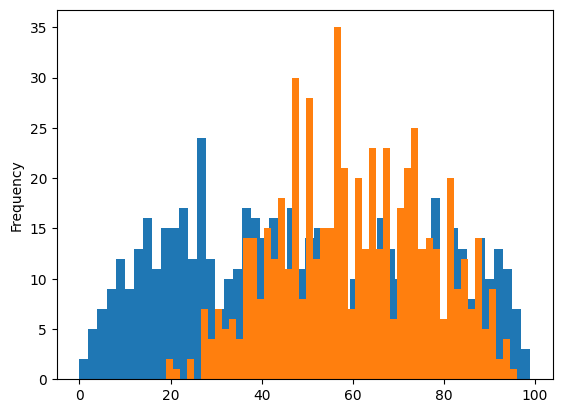

In [45]:
df["RottenTomatoes"].plot.hist(bins=50)
df["AudienceScore"].plot.hist(bins=50)
plt.show()

#### 3. Хи-квадрат

In [33]:
genres = ["Comedy", "Action", "Drama"]
studios = ["Warner Bros", "Sony", "Fox"]

In [34]:
df_ = df[df["Genre"].isin(genres) & df["LeadStudio"].isin(studios)]

cross = pd.crosstab(df_["Genre"], df_["LeadStudio"])
chi2, p, dof, expected = stats.chi2_contingency(cross)
print(chi2, p)

4.085201327235226 0.39459789005245166


In [35]:
cross["Fox"]

Genre
Action    20
Comedy    20
Drama      5
Name: Fox, dtype: int64

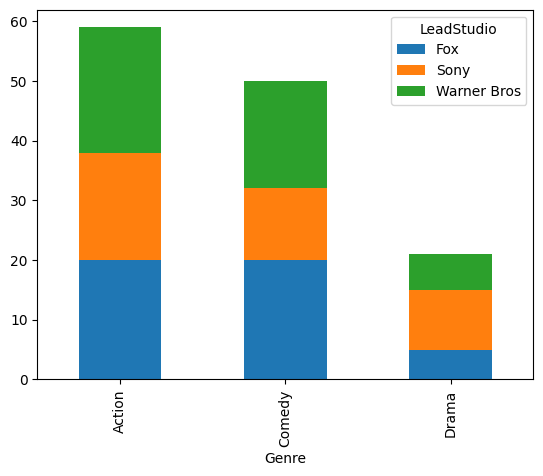

In [36]:
cross.plot(kind="bar", stacked=True)
plt.show()

#### 4. Однофакторный дисперсионный анализ ANOVA

In [37]:
groups = [df[df["Genre"] == g]["Budget"] for g in genres]
stat, p = stats.f_oneway(*groups)
print(stat, p)

56.42011704102207 3.6162709198288884e-22


#### 5. Линейная регрессия (линия тренда)

R2 0.4705614262448686


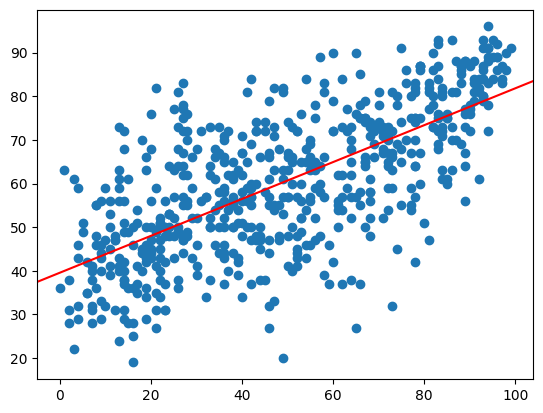

In [29]:
res = stats.linregress(df["RottenTomatoes"], df["AudienceScore"])

plt.scatter(df["RottenTomatoes"], df["AudienceScore"])
plt.axline((0, res.intercept), slope=res.slope, color="red")

print("R2", res.rvalue ** 2)

#### 6. Непараметрический тест Манна-Уитни

In [41]:
stat, p = stats.mannwhitneyu(comedy_budgets, drama_budgets)
print(stat, p)

6715.0 0.10056694726008811


### Задания для самостоятельного выполнения

#### Задание 1

Найдите три достаточно больших текста разных жанров.

(а) проанализируйте их с помошью pymorphy и определите, есть ли разница в употреблении падежей.

(б) определите, есть ли разница в длинах предложений.

#### Задание 2

https://drive.google.com/drive/folders/1HoZKucFg5y87YMfnmkt7-n1a5iHlSPQP?usp=sharing

Дан фрагмент разметки диалогового корпуса SibLing. Доступны два уровня: "turns" &mdash; реплики и "ipu" &mdash; паузы. Название каждого файла устроено по схеме: `номердиалога_номердиктора_типзадания.TextGrid`. В таблице sibling_speakers.csv дана информация о поле и возрасте дикторов. В таблице dialogue_types.csv дана информация о типе каждого диалога, определяемого по последней цифре номера: диалог между братьями/сёстрами, друзьями, незнакомцами одного или разного пола, диалог, в котором один диктор значительно старше другого и занимает руководящую должность ("босс").

Определите, зависит ли длительность внутрирепликовых пауз от следующих параметров: тип задания, возраст и пол говорящего, тип диалога.

https://www.researchgate.net/publication/341608926_SibLing_Corpus_of_Russian_Dialogue_Speech_Designed_for_Researchon_Speech_Entrainment